# Laboratorio 4: Regresión Logística Multiclase (One-vs-All)
### Clasificador de Tráfico de Red (Dataset CIC-Darknet2020)

Estudiante: Valencia Medina Freddy Daniel

Dataset: CIC-Darknet2020

https://www.kaggle.com/datasets/dhoogla/cicdarknet2020

n = 79 caracteristicas
m = 103121 filas


In [1]:
#importacion de librerias
import os
import time
import numpy as np
import pandas as pd
from matplotlib import pyplot
from scipy import optimize
%matplotlib inline

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


/kaggle/input/datasets/dhoogla/cicdarknet2020/cicdarknet2020.parquet


## 1. Carga y Análisis Exploratorio de Datos (EDA)
Leemos el dataset original almacenado en formato `.parquet` utilizando `pandas`. Adicionalmente, aplicamos un paso crucial de **normalización de etiquetas**: transformamos todos los valores a minúsculas y eliminamos espacios en blanco, previniendo que actividades idénticas representen múltiples clases por errores tipográficos. 

In [2]:
df = pd.read_parquet('/kaggle/input/datasets/dhoogla/cicdarknet2020/cicdarknet2020.parquet')

print('m y n del dataset')
print(df.shape)

pd.set_option('display.max_rows', None)
print('\n tipos de columnas')
print(df.dtypes)

#imprimimos antes de hacer la normalizacion
print('\n Distribución de Label.1 (tipo de actividad)')
print(df['Label.1'].value_counts())

# normalizamos todo con minusculas
df['Label.1'] = df['Label.1'].astype(str).str.lower().str.strip()
df['Label.1'] = df['Label.1'].str.replace('-', '_')

#imprimimos la otra alternativa
print('\n Distribución de Label (tipo de red)')
print(df['Label'].value_counts())

print('\n Distribución de Label.1 (tipo de actividad)')
print(df['Label.1'].value_counts())

print(f'\nClases únicas en Label.1: {df["Label.1"].nunique()}')

m y n del dataset
(103121, 79)

 tipos de columnas
Protocol                          int8
Flow Duration                    int32
Total Fwd Packet                 int32
Total Bwd packets                int32
Total Length of Fwd Packet       int32
Total Length of Bwd Packet       int32
Fwd Packet Length Max            int32
Fwd Packet Length Min            int16
Fwd Packet Length Mean         float32
Fwd Packet Length Std          float32
Bwd Packet Length Max            int32
Bwd Packet Length Min            int16
Bwd Packet Length Mean         float32
Bwd Packet Length Std          float32
Flow Bytes/s                   float64
Flow Packets/s                 float64
Flow IAT Mean                  float32
Flow IAT Std                   float32
Flow IAT Max                     int32
Flow IAT Min                     int32
Fwd IAT Total                    int32
Fwd IAT Mean                   float32
Fwd IAT Std                    float32
Fwd IAT Max                      int32
Fwd IAT Min  

## 2. Limpieza de Datos (Filtrado de Infinitos y Nulos)
Revisamos si la matriz de características (`X`) contiene un solo valor `NaN` (no numérico) o un elemento que se interpreta como infinito (`np.inf`),  para evitar que las multiplicaciones matriciales fallen

In [3]:
df_check = df.drop(columns=['Label', 'Label.1'])

# Nulos por columna (solo las que tienen)
nulos = df_check.isnull().sum()
nulos_existentes = nulos[nulos > 0]

print('Columnas con valores nulos')
if len(nulos_existentes) == 0:
    print('No hay columnas con nulos')
else:
    print(nulos_existentes)
    print(f'\nTotal filas afectadas: {df_check.isnull().any(axis=1).sum()}')

# Infinitos por columna
inf_pos = (df_check == np.inf).sum()
inf_neg = (df_check == -np.inf).sum()
inf_existentes = (inf_pos + inf_neg)
inf_existentes = inf_existentes[inf_existentes > 0]

print('\nColumnas con infinitos')
if len(inf_existentes) == 0:
    print('No hay columnas con infinitos')
else:
    print(inf_existentes)
    print(f'\nTotal filas afectadas: '
          f'{((df_check == np.inf) | (df_check == -np.inf)).any(axis=1).sum()}')

print(f'\nTotal filas del dataset: {df.shape[0]}')

Columnas con valores nulos
No hay columnas con nulos

Columnas con infinitos
No hay columnas con infinitos

Total filas del dataset: 103121


## 3. Partición de Variables e Inyección Matricial Numpy
Extraemos las columnas de las características (todas menos los Labels) para construir nuestra matriz principal matemática `X_raw`. Igualmente, apartamos el vector objetivo (`y_raw`), extrayendo ambos nativamente en flotantes de 64-bits listos para que NumPy los opere.

In [4]:
target_col = 'Label.1'

# Separar features y etiqueta
X_raw_df = df.drop(columns=['Label', 'Label.1'])
y_raw    = df[target_col].values

X_raw = X_raw_df.values.astype(np.float64)

print(f'Filas    : {X_raw.shape[0]}')
print(f'Features : {X_raw.shape[1]}')
print(f'\nClases únicas en Label.1:')
for c in np.unique(y_raw):
    print(f'  {c}: {np.sum(y_raw == c)}')
print(f'\nTotal clases: {len(np.unique(y_raw))}')

Filas    : 103121
Features : 77

Clases únicas en Label.1:
  audio_streaming: 11328
  browsing: 29862
  chat: 10365
  email: 5442
  file_transfer: 10647
  p2p: 23404
  video_streaming: 9012
  voip: 3061

Total clases: 8


## 4. Codificación Numérica de Clases ("Categorical Encoding")
Transformamos cada categoría en texto de texto plano (ej: `browsing, chat,email,etc`) a un número entero del `0` al `7` creando y conservando un diccionario bidireccional (`clase_a_idx` y `idx_a_clase`) para traducirlo a voluntad.

In [5]:
# Codificación texto → entero
clases      = np.unique(y_raw)
clase_a_idx = {c: i for i, c in enumerate(clases)}
idx_a_clase = {i: c for c, i in clase_a_idx.items()}
num_labels  = len(clases)

y_encoded = np.array([clase_a_idx[c] for c in y_raw])

print('Mapeo de clases:')
for c in range(num_labels):
    print(f'  {c} → {idx_a_clase[c]:20s} ({np.sum(y_encoded == c)} muestras)')
print(f'\nTotal clases: {num_labels}')

Mapeo de clases:
  0 → audio_streaming      (11328 muestras)
  1 → browsing             (29862 muestras)
  2 → chat                 (10365 muestras)
  3 → email                (5442 muestras)
  4 → file_transfer        (10647 muestras)
  5 → p2p                  (23404 muestras)
  6 → video_streaming      (9012 muestras)
  7 → voip                 (3061 muestras)

Total clases: 8


## 5. División de Set de Entrenamiento y Prueba (Train/Test Split) Pre Balanceo
Para evitar el **Data Leakage** (Fuga de Datos), la partición debe hacerse utilizando los datos crudos originales, antes de cualquier inyección artificial de balanceo. Evaluaremos nuestro modelo final sobre datos de prueba (`X_test`) que el sistema jamás observó durante su balanceo y que mantienen sus proporciones duras del mundo real. Hacemos el corte `80%` a `20%`.

In [6]:
m_total = X_raw.shape[0]
m_train = int(0.8 * m_total)

np.random.seed(42)
indices   = np.random.permutation(m_total)
train_idx = indices[:m_train]
test_idx  = indices[m_train:]

# Sets crudos divisionales
X_train_raw = X_raw[train_idx]
y_train_raw = y_encoded[train_idx]
X_test_raw  = X_raw[test_idx]
y_test      = y_encoded[test_idx]  # El Test no cambia de tamaño nunca más

print(f'Total muestras : {m_total}')
print(f'Entrenamiento Crudo : {X_train_raw.shape[0]} ({X_train_raw.shape[0]/m_total*100:.0f}%)')
print(f'Prueba (Test)       : {X_test_raw.shape[0]}  ({X_test_raw.shape[0]/m_total*100:.0f}%)')

print(f'\nDistribución en el Entrenamiento Crudo:')
for c in range(num_labels):
    print(f'  {idx_a_clase[c]:20s}: {np.sum(y_train_raw == c)}')

print(f'\nDistribución INTACTA en Prueba (Nunca se balanceará):')
for c in range(num_labels):
    print(f'  {idx_a_clase[c]:20s}: {np.sum(y_test == c)}')

Total muestras : 103121
Entrenamiento Crudo : 82496 (80%)
Prueba (Test)       : 20625  (20%)

Distribución en el Entrenamiento Crudo:
  audio_streaming     : 9060
  browsing            : 23732
  chat                : 8308
  email               : 4391
  file_transfer       : 8581
  p2p                 : 18777
  video_streaming     : 7214
  voip                : 2433

Distribución INTACTA en Prueba (Nunca se balanceará):
  audio_streaming     : 2268
  browsing            : 6130
  chat                : 2057
  email               : 1051
  file_transfer       : 2066
  p2p                 : 4627
  video_streaming     : 1798
  voip                : 628


## 6. Balanceo Híbrido NumPy Aplicado solo al Entrenamiento
El dataset esta desbalanceado lo que en la regresion logistica one vs all puede aprender patrones predominantes para lo cual aplicaremos
- **Undersampling:** Reduciremos las clases gigantes al número objetivo.
- **SMOTE (Tecnica de Sobremuestreo sintetico de minorias):** Recrearemos muestras artificiales para las minoritarias trazando líneas de distancia.
- 
**Decisión de 10,000 Muestras:** El proceso sera únicamente sobre `X_train_raw` generando nuestro definitivo set procesado `X_train_bal`. 

In [7]:
def smote_manual(X_clase, n_sinteticos, k=10, seed=42):
    """
    Genera n_sinteticos ejemplos sintéticos interpolando
    entre vecinos cercanos de la misma clase.
    """
    np.random.seed(seed)
    n_real = X_clase.shape[0]
    sinteticos = []

    for _ in range(n_sinteticos):
        idx    = np.random.randint(0, n_real)
        muestra = X_clase[idx]

        distancias = np.sqrt(np.sum((X_clase - muestra) ** 2, axis=1))
        distancias[idx] = np.inf

        vecinos_idx = np.argsort(distancias)[:k]
        vecino      = X_clase[np.random.choice(vecinos_idx)]

        lam   = np.random.uniform(0, 1)
        nuevo = muestra + lam * (vecino - muestra)
        sinteticos.append(nuevo)

    return np.array(sinteticos)

objetivo = 10000
np.random.seed(42)

start_time_smote = time.time()

X_bal_list = []
y_bal_list = []

for c in range(num_labels):
    # balanceamos solo datos para entrenamiento
    X_clase = X_train_raw[y_train_raw == c]
    n_real  = X_clase.shape[0]
    nombre  = idx_a_clase[c]

    if n_real >= objetivo:
        idx_sel = np.random.choice(n_real, objetivo, replace=False)
        X_final = X_clase[idx_sel]
        accion  = 'Undersampling'
    else:
        n_sinteticos = objetivo - n_real
        X_sint  = smote_manual(X_clase, n_sinteticos, k=5, seed=42)
        X_final = np.vstack([X_clase, X_sint])
        accion  = f'SMOTE (+{n_sinteticos} sintéticos)'

    X_bal_list.append(X_final)
    y_bal_list.append(np.full(objetivo, c))

    print(f'  {nombre:20s} | en_train: {n_real:6d} | {accion}')

X_train_bal = np.vstack(X_bal_list)
y_train_bal = np.concatenate(y_bal_list)

idx_shuffle = np.random.permutation(len(y_train_bal))
X_train_bal = X_train_bal[idx_shuffle]
y_train     = y_train_bal[idx_shuffle]

time_smote = time.time() - start_time_smote

print(f'\nResumen del Dataset Train Balanceado')
print(f'Muestras entrenables : {X_train_bal.shape[0]}')
print(f'Tiempo en ejecución de Balanceo: {time_smote:.2f} segundos')

print(f'\nDistribución final en Training:')
for c in range(num_labels):
    print(f'  {idx_a_clase[c]:20s}: {np.sum(y_train == c)}')

  audio_streaming      | en_train:   9060 | SMOTE (+940 sintéticos)
  browsing             | en_train:  23732 | Undersampling
  chat                 | en_train:   8308 | SMOTE (+1692 sintéticos)
  email                | en_train:   4391 | SMOTE (+5609 sintéticos)
  file_transfer        | en_train:   8581 | SMOTE (+1419 sintéticos)
  p2p                  | en_train:  18777 | Undersampling
  video_streaming      | en_train:   7214 | SMOTE (+2786 sintéticos)
  voip                 | en_train:   2433 | SMOTE (+7567 sintéticos)

Resumen del Dataset Train Balanceado
Muestras entrenables : 80000
Tiempo en ejecución de Balanceo: 27.19 segundos

Distribución final en Training:
  audio_streaming     : 10000
  browsing            : 10000
  chat                : 10000
  email               : 10000
  file_transfer       : 10000
  p2p                 : 10000
  video_streaming     : 10000
  voip                : 10000


## 7. Normalización Vectorizada ($Z$-score)
Las características en nuestro dataset de red tienen dimensiones mixtas (algunas miden conteos enteros pequeños, otras miden distancias gigantes de los paquetes byte). Es por eso que popnemos todas estas dimensiones a la misma proporción y con media 0. 
 Se calcula $\mu$ y $\sigma$ solamente a los datos de entrenamiento para prevenir la Fuga de Datos. Luego usamos esos valores para proyectar el Test.                                           

In [8]:
def featureNormalize(X_train, X_test):
    mu    = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)
    sigma[sigma == 0] = 1

    X_train_norm = (X_train - mu) / sigma
    X_test_norm  = (X_test  - mu) / sigma
    return X_train_norm, X_test_norm, mu, sigma


In [9]:

#Calculamos la normalización puramente desde X_train_bal
X_train, X_test, mu, sigma = featureNormalize(X_train_bal, X_test_raw)

print(f'X_train : {X_train.shape}')
print(f'X_test  : {X_test.shape}')
print(f'Media primera feature (debe ser ≈0) : {X_train[:,0].mean():.6f}')
print(f'Std  primera feature (debe ser ≈1)  : {X_train[:,0].std():.6f}')

X_train : (80000, 77)
X_test  : (20625, 77)
Media primera feature (debe ser ≈0) : -0.000000
Std  primera feature (debe ser ≈1)  : 1.000000


In [10]:
print(f'{"#":<4} {"Feature":<35} {"Media":>12} {"Std":>12} {"Min":>10} {"Max":>10}')
print('-' * 80)

for i in range(X_train.shape[1]):
    nombre = X_raw_df.columns[i]
    media  = X_train[:, i].mean()
    std    = X_train[:, i].std()
    minimo = X_train[:, i].min()
    maximo = X_train[:, i].max()
    print(f'{i:<4} {nombre:<35} {media:>12.4f} {std:>12.4f} {minimo:>10.2f} {maximo:>10.2f}')

#    Feature                                    Media          Std        Min        Max
--------------------------------------------------------------------------------
0    Protocol                                 -0.0000       1.0000      -2.07       0.96
1    Flow Duration                             0.0000       1.0000      -0.56       2.43
2    Total Fwd Packet                         -0.0000       1.0000      -0.08      74.84
3    Total Bwd packets                        -0.0000       1.0000      -0.05      99.38
4    Total Length of Fwd Packet               -0.0000       1.0000      -0.05     128.41
5    Total Length of Bwd Packet               -0.0000       1.0000      -0.03      99.52
6    Fwd Packet Length Max                     0.0000       1.0000      -0.29      62.20
7    Fwd Packet Length Min                     0.0000       1.0000      -0.60      38.90
8    Fwd Packet Length Mean                    0.0000       1.0000      -0.33     108.84
9    Fwd Packet Length Std   

## 8. Funciones Base Vectorizadas
### 8.1 Sigmoide
Calcula $g(z) = \frac{1}{1+e^{-z}}$. Limitamos usando `np.clip` para evitar el colapso al trabajar con número gigantes de red (`Overflow`)

In [11]:
def sigmoid(z):
    """
    Calcula la función sigmoide de z.
    Se limita z entre -500 y 500 para evitar overflow en exp.
    """
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

### 8.2 Función de Costo de Regresión Logística (No regularizado)
Escribimos la función matemática donde implementamos mediante productos punto el cálculo de la entropía cruzada binaria ($J(\theta)$). Se previene que el $\log(0)$ de paso a $-\infty$ acotando el dominio (`clip`).

In [12]:
def calcularCosto(theta, X, y):
    """
    Calcula el costo de regresión logística sin regularización.
    theta : vector (n+1,)
    X     : matriz (m, n+1) — ya incluye columna de unos
    y     : vector binario (m,) para una clase específica
    """
    m = y.size
    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)  # evitar log(0)
    J = (1/m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h))
    return J

### 8.3 Descenso por Graiente
Se aplica el ajuste manual de Theta dado iteración de la derivada $\frac{\partial J }{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^m \left( \left( h_\theta\left(x^{(i)}\right) - y^{(i)} \right)x_j^{(i)} \right)$.

In [13]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    """
    Actualiza theta iterativamente minimizando el costo.
    Retorna theta optimizado y el historial de costos J_history.
    
    theta     : vector inicial (n+1,)
    X         : matriz (m, n+1) con columna de unos
    y         : vector binario (m,) para una clase
    alpha     : tasa de aprendizaje
    num_iters : número de iteraciones
    """
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h     = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)
        J_history.append(calcularCosto(theta, X, y))

    return theta, J_history

### 8.4 Función de Costo de Regresión Logística (Regularizada)
Penaliza el crecimiento de los pesos (`theta`) agregando $\frac{\lambda}{2m} \sum \theta^2$ omitiendo el sesgo ($\theta_0$). Esto prepara la matriz hacia el optimizador avanzado `Scipy`.

In [14]:
def lrCostFunction(theta, X, y, lambda_):
    """
    Costo regularizado L2 + gradiente para scipy.optimize.
    No regulariza theta[0] (bias).
    Retorna (J, grad).
    """
    m = y.size

    if y.dtype == bool:
        y = y.astype(int)

    h = sigmoid(X.dot(theta.T))
    h = np.clip(h, 1e-10, 1 - 1e-10)

    temp    = theta.copy()
    temp[0] = 0  # no regularizar el bias

    J    = (1/m) * np.sum(-y * np.log(h) - (1 - y) * np.log(1 - h)) \
           + (lambda_ / (2*m)) * np.sum(np.square(temp))
    grad = (1/m) * (h - y).dot(X) + (lambda_/m) * temp

    return J, grad

## 9. Entrenamiento "Uno-Contra-Todos" (1-vs-All)
En lugar de entrenar una red de `K` salidas, este algoritmo entrena un modelo binario de Sí/No `K` veces, almacenando en una matriz gigante (`all_theta`) los pesos que resulten de cada iteración, permitiendo saber "qué clase" tiene más sentido luego.
La primera función emplea el **Descenso manual** iterativo.

In [15]:
def OneVsAll(X, y, num_labels, alpha, num_iters):
    """
    Entrena num_labels clasificadores binarios con descenso por gradiente.
    Uno por cada clase contra todas las demás.
    Retorna all_theta (num_labels, n+1) y el historial de costos.
    """
    m, n = X.shape
    all_theta     = np.zeros((num_labels, n + 1))
    all_J_history = []

    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        y_c = np.where(y == c, 1, 0).astype(float)

        theta, J_history = descensoGradiente(initial_theta, X_b, y_c, alpha, num_iters)
        all_theta[c]     = theta
        all_J_history.append(J_history)

        # Resumen por clase
        J_inicial  = J_history[0]
        J_final    = J_history[-1]
        reduccion  = ((J_inicial - J_final) / J_inicial) * 100
        print(f'  Clase {c} ({idx_a_clase[c]:20s}) → '
              f'costo inicial: {J_inicial:.4f} | '
              f'costo final: {J_final:.4f} | '
              f'reducción: {reduccion:.1f}%')

    return all_theta, all_J_history

Esta segunda función `OneVsAllOM` realiza lo mismo pero utilizando `scipy.optimize.minimize`, un algoritmo más rápido que evalúa las tangentes usando un Gradiente Conjugado.

In [16]:
def OneVsAllOM(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n + 1))
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)

    for c in range(num_labels):
        initial_theta = np.zeros(n + 1)
        options       = {'maxiter': 500}

        # Calculamos costo inicial antes de que scipy optimice
        J_inicial, _ = lrCostFunction(initial_theta, X_b, (y == c), lambda_)

        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X_b, (y == c), lambda_),
            jac=True,
            method='CG',
            options=options
        )
        all_theta[c] = res.x

        J_final   = res.fun
        reduccion = ((J_inicial - J_final) / J_inicial) * 100

        print(f'  Clase {c} ({idx_a_clase[c]:20s}) → '
              f'costo inicial: {J_inicial:.4f} | '
              f'costo final: {J_final:.4f} | '
              f'reducción: {reduccion:.1f}%')

    return all_theta

## 10. Función de Predicción `predictOneVsAll`
Recibe la matriz entrenada (`all_theta`), inyecta los `1` correspondientes al sesgo, computa el logístico para predecir las $K$  probabilidades por cada registro y elige al ganador numérico usando la máxima (`np.argmax`).

In [17]:
def predictOneVsAll(all_theta, X):
    """
    Predice la clase de cada ejemplo en X.
    Evalúa los K clasificadores y elige el de mayor probabilidad.
    Retorna vector de predicciones (m,).
    """
    m   = X.shape[0]
    X_b = np.concatenate([np.ones((m, 1)), X], axis=1)
    # Para cada ejemplo, elegir la clase con mayor probabilidad
    p   = np.argmax(sigmoid(X_b.dot(all_theta.T)), axis=1)
    return p

## 11. Ejecución del Entrenamiento Multiclase
Ajustaremos nuestros hiperparámetros (ratio de aprendizaje `alpha`, y pasadas `num_iters`), y levantaremos los dos algoritmos para generar las respectivas matrices `Theta`.

In [18]:

# Hiperparámetros
alpha     = 0.1
num_iters = 3000
lambda_   = 0.01


In [19]:

# Método 1: Descenso por Gradiente

print('Entrenando con Descenso por Gradiente...')
print(f'alpha={alpha}, iteraciones={num_iters}')


start_time_gd = time.time()
all_theta_gd, all_J_history = OneVsAll(X_train, y_train, num_labels, alpha, num_iters)
time_gd = time.time() - start_time_gd

print(f'Entrenamiento GD completado (Tomó: {time_gd:.2f} segundos)')


Entrenando con Descenso por Gradiente...
alpha=0.1, iteraciones=3000
  Clase 0 (audio_streaming     ) → costo inicial: 0.6770 | costo final: 0.3028 | reducción: 55.3%
  Clase 1 (browsing            ) → costo inicial: 0.6760 | costo final: 0.2585 | reducción: 61.8%
  Clase 2 (chat                ) → costo inicial: 0.6751 | costo final: 0.3241 | reducción: 52.0%
  Clase 3 (email               ) → costo inicial: 0.6755 | costo final: 0.2996 | reducción: 55.7%
  Clase 4 (file_transfer       ) → costo inicial: 0.6744 | costo final: 0.3164 | reducción: 53.1%
  Clase 5 (p2p                 ) → costo inicial: 0.6743 | costo final: 0.2353 | reducción: 65.1%
  Clase 6 (video_streaming     ) → costo inicial: 0.6754 | costo final: 0.3077 | reducción: 54.4%
  Clase 7 (voip                ) → costo inicial: 0.6742 | costo final: 0.2651 | reducción: 60.7%
Entrenamiento GD completado (Tomó: 394.21 segundos)


In [20]:

# Método 2: Scipy Optimize

print('Entrenando con Scipy (Conjugate Gradient)...')
print(lambda_)
start_time_om = time.time()
all_theta_om = OneVsAllOM(X_train, y_train, num_labels, lambda_)
time_om = time.time() - start_time_om

print(f'Entrenamiento Scipy completado (Tomó: {time_om:.2f} segundos)')

Entrenando con Scipy (Conjugate Gradient)...
0.01
  Clase 0 (audio_streaming     ) → costo inicial: 0.6931 | costo final: 0.2975 | reducción: 57.1%
  Clase 1 (browsing            ) → costo inicial: 0.6931 | costo final: 0.2471 | reducción: 64.4%
  Clase 2 (chat                ) → costo inicial: 0.6931 | costo final: 0.3219 | reducción: 53.6%
  Clase 3 (email               ) → costo inicial: 0.6931 | costo final: 0.2880 | reducción: 58.5%
  Clase 4 (file_transfer       ) → costo inicial: 0.6931 | costo final: 0.3122 | reducción: 55.0%
  Clase 5 (p2p                 ) → costo inicial: 0.6931 | costo final: 0.2037 | reducción: 70.6%
  Clase 6 (video_streaming     ) → costo inicial: 0.6931 | costo final: 0.3050 | reducción: 56.0%
  Clase 7 (voip                ) → costo inicial: 0.6931 | costo final: 0.2519 | reducción: 63.7%
Entrenamiento Scipy completado (Tomó: 91.06 segundos)


## 12. Curvas de Convergencia por Descenso de Gradiente Manual
Imprimimos en Matplotlib el ritmo de aprendizaje de nuestros algoritmos por clase.

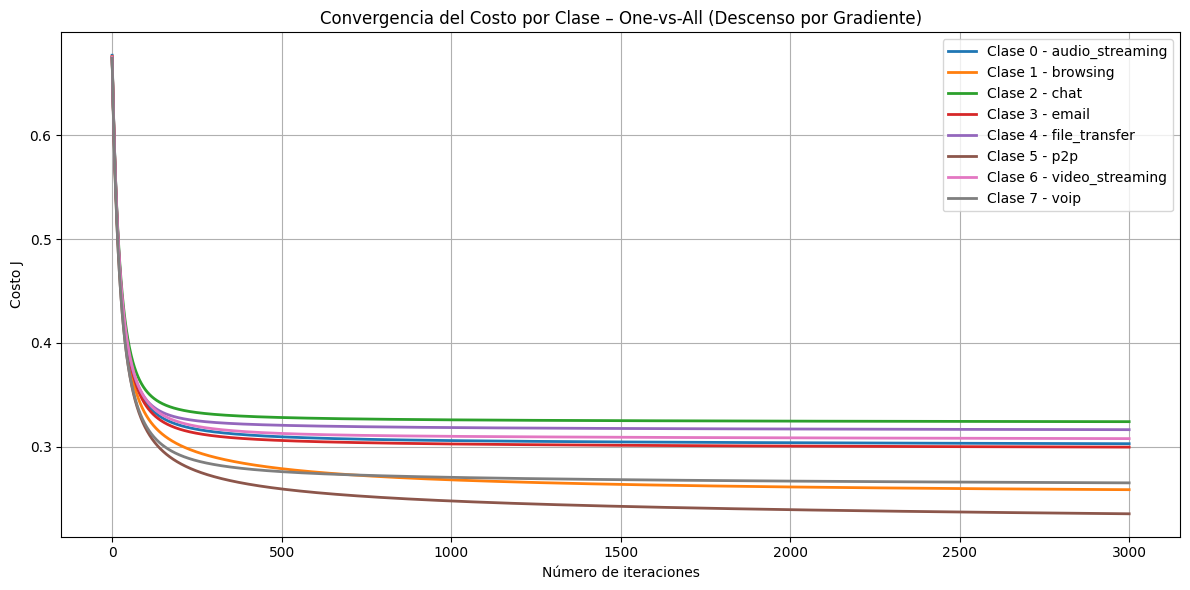

In [21]:
pyplot.figure(figsize=(12, 6))

for c in range(num_labels):
    pyplot.plot(
        np.arange(len(all_J_history[c])),
        all_J_history[c],
        lw=2,
        label=f'Clase {c} - {idx_a_clase[c]}'
    )

pyplot.xlabel('Número de iteraciones')
pyplot.ylabel('Costo J')
pyplot.title('Convergencia del Costo por Clase – One-vs-All (Descenso por Gradiente)')
pyplot.legend(loc='upper right')
pyplot.grid(True)
pyplot.tight_layout()
pyplot.show()


🚀 Iniciando análisis de aprendizaje manual...
  Clase 0 (audio_streaming     ) → costo inicial: 0.6915 | costo final: 0.3922 | reducción: 43.3%
  Clase 1 (browsing            ) → costo inicial: 0.6914 | costo final: 0.3836 | reducción: 44.5%
  Clase 2 (chat                ) → costo inicial: 0.6913 | costo final: 0.3948 | reducción: 42.9%
  Clase 3 (email               ) → costo inicial: 0.6913 | costo final: 0.3878 | reducción: 43.9%
  Clase 4 (file_transfer       ) → costo inicial: 0.6912 | costo final: 0.3968 | reducción: 42.6%
  Clase 5 (p2p                 ) → costo inicial: 0.6911 | costo final: 0.3753 | reducción: 45.7%
✅ m=10000 finalizado | Acc: 46.66%
  Clase 0 (audio_streaming     ) → costo inicial: 0.6915 | costo final: 0.3922 | reducción: 43.3%
  Clase 1 (browsing            ) → costo inicial: 0.6914 | costo final: 0.3830 | reducción: 44.6%
  Clase 2 (chat                ) → costo inicial: 0.6913 | costo final: 0.3960 | reducción: 42.7%
  Clase 3 (email               ) → co

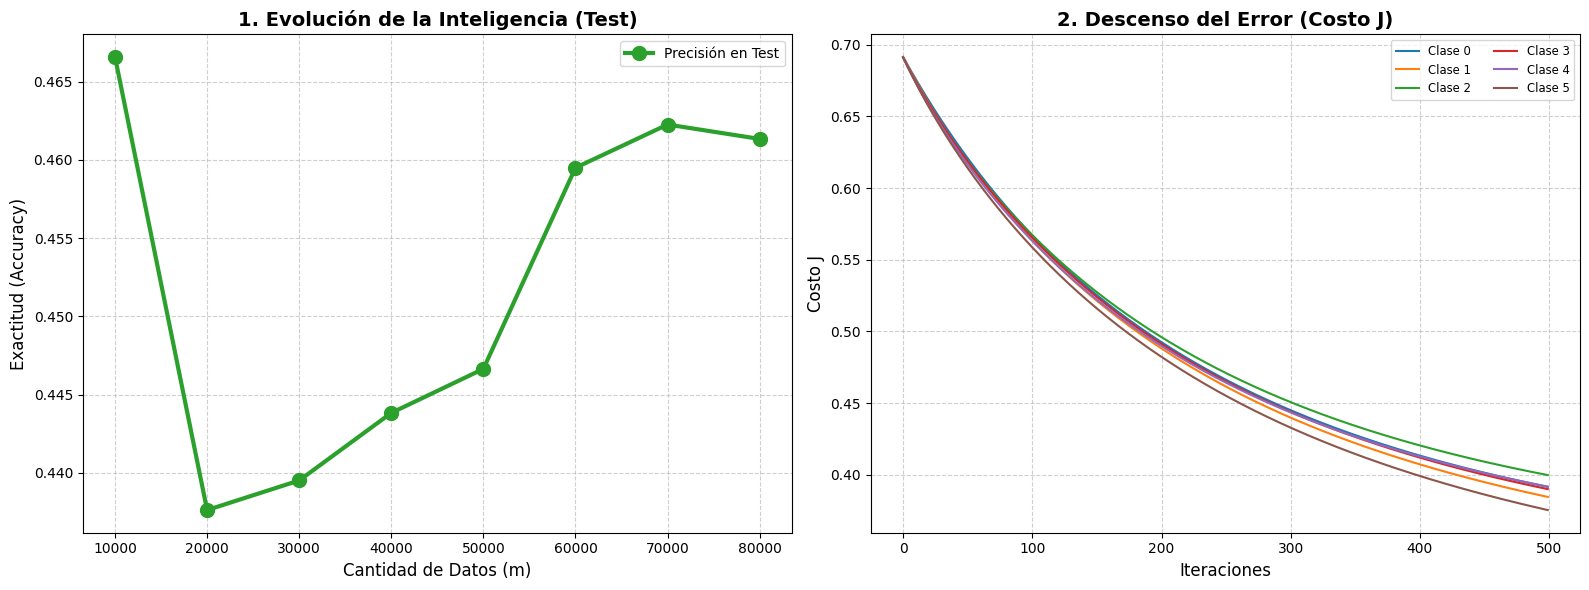

In [45]:
import numpy as np
import matplotlib.pyplot as plt

def visualizar_rendimiento_completo(X_train, y_train, X_test, y_test, num_labels, lambda_val):
    # Ajustamos para tener 6-8 puntos de control para que no tarde una eternidad
    paso = max(1, len(X_train) // 8) 
    m_sizes = np.arange(paso, len(X_train) + 1, paso)
    precisiones = []
    
    print("🚀 Iniciando análisis de aprendizaje manual...")
    
    for m in m_sizes:
        X_sub = X_train[:m]
        y_sub = y_train[:m]
        
        # CAMBIO CLAVE: Usamos 'OneVsAll' con O mayúscula como tú la definiste
        # Si prefieres usar la de Scipy, cámbiala por: OneVsAllOM(X_sub, y_sub, num_labels, lambda_val)
        theta_tmp, cost_hist_tmp = OneVsAll(X_sub, y_sub, num_labels, 0.01, 500) 
        
        preds = predictOneVsAll(theta_tmp, X_test)
        acc = np.mean(preds == y_test)
        precisiones.append(acc)
        print(f"✅ m={m} finalizado | Acc: {acc*100:.2f}%")

    # --- GENERACIÓN DE GRÁFICAS ---
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Gráfica A: Curva de Aprendizaje
    ax1.plot(m_sizes, precisiones, 'o-', color='#2ca02c', linewidth=3, markersize=10, label='Precisión en Test')
    ax1.set_title("1. Evolución de la Inteligencia (Test)", fontsize=14, fontweight='bold')
    ax1.set_xlabel("Cantidad de Datos (m)", fontsize=12)
    ax1.set_ylabel("Exactitud (Accuracy)", fontsize=12)
    ax1.grid(True, linestyle='--', alpha=0.6)
    ax1.legend()

    # Gráfica B: Convergencia de Costo
    for c in range(num_labels):
        ax2.plot(cost_hist_tmp[c], label=f'Clase {c}')
    
    ax2.set_title("2. Descenso del Error (Costo J)", fontsize=14, fontweight='bold')
    ax2.set_xlabel("Iteraciones", fontsize=12)
    ax2.set_ylabel("Costo J", fontsize=12)
    ax2.grid(True, linestyle='--', alpha=0.6)
    ax2.legend(loc='upper right', fontsize='small', ncol=2)

    plt.tight_layout()
    plt.show()

# --- LLAMADA A LA FUNCIÓN ---
# Usamos X_train y y_train (sin el _norm) porque así los nombraste tú
visualizar_rendimiento_completo(X_train, y_train, X_test, y_test, num_labels=6, lambda_val=0.1)

## 13. Obtención y Evaluación de Resultados (`Accuracy`)
La métrica real de éxito se mide contra nuestro `X_test` y la `y_test`. Extraeremos los valores de porcentaje de cuántos aciertos se tuvo dividiendo los ganadores con los objetivos reales. Adicionalmente, verificaremos la precisión clase por clase.

In [23]:
# Predicciones
pred_train_gd = predictOneVsAll(all_theta_gd, X_train)
pred_test_gd  = predictOneVsAll(all_theta_gd, X_test)

pred_train_om = predictOneVsAll(all_theta_om, X_train)
pred_test_om  = predictOneVsAll(all_theta_om, X_test)

# Precisión global
acc_train_gd = np.mean(pred_train_gd == y_train) * 100
acc_test_gd  = np.mean(pred_test_gd  == y_test)  * 100
acc_train_om = np.mean(pred_train_om == y_train) * 100
acc_test_om  = np.mean(pred_test_om  == y_test)  * 100


print('PRECISIÓN GLOBAL')

print(f'Método              | Entrenamiento | Prueba')

print(f'Descenso Gradiente  |   {acc_train_gd:6.2f}%    | {acc_test_gd:.2f}%')
print(f'Scipy (CG)          |   {acc_train_om:6.2f}%    | {acc_test_om:.2f}%')

#Precisión por clase (usando Scipy como modelo final)
print('\n Precisión por clase – Conjunto de Prueba (Scipy)')
for c in range(num_labels):
    mask  = (y_test == c)
    acc_c = np.mean(pred_test_om[mask] == y_test[mask]) * 100
    print(f'  {idx_a_clase[c]:20s}: {acc_c:.2f}%')

PRECISIÓN GLOBAL
Método              | Entrenamiento | Prueba
Descenso Gradiente  |    47.18%    | 55.61%
Scipy (CG)          |    49.51%    | 57.67%

 Precisión por clase – Conjunto de Prueba (Scipy)
  audio_streaming     : 53.88%
  browsing            : 69.82%
  chat                : 20.08%
  email               : 23.79%
  file_transfer       : 29.28%
  p2p                 : 85.54%
  video_streaming     : 39.27%
  voip                : 73.25%


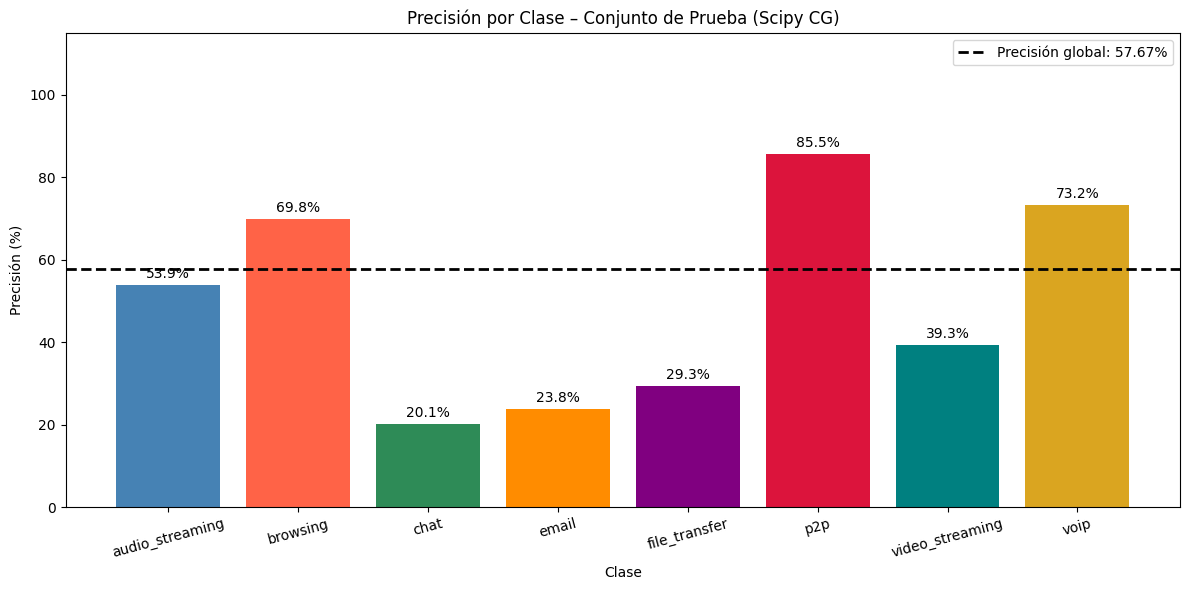

In [24]:
nombres_clases       = [idx_a_clase[c] for c in range(num_labels)]
precisiones_por_clase = []

for c in range(num_labels):
    mask  = (y_test == c)
    acc_c = np.mean(pred_test_om[mask] == y_test[mask]) * 100
    precisiones_por_clase.append(acc_c)

colores = ['steelblue','tomato','seagreen','darkorange',
           'purple','crimson','teal','goldenrod']

pyplot.figure(figsize=(12, 6))
bars = pyplot.bar(nombres_clases, precisiones_por_clase, color=colores)
pyplot.axhline(
    y=acc_test_om,
    color='black',
    linestyle='--',
    linewidth=2,
    label=f'Precisión global: {acc_test_om:.2f}%'
)
pyplot.xlabel('Clase')
pyplot.ylabel('Precisión (%)')
pyplot.title('Precisión por Clase – Conjunto de Prueba (Scipy CG)')
pyplot.ylim([0, 115])
pyplot.xticks(rotation=15)
pyplot.legend()
for bar, val in zip(bars, precisiones_por_clase):
    pyplot.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 1,
        f'{val:.1f}%',
        ha='center', va='bottom', fontsize=10
    )
pyplot.tight_layout()
pyplot.show()

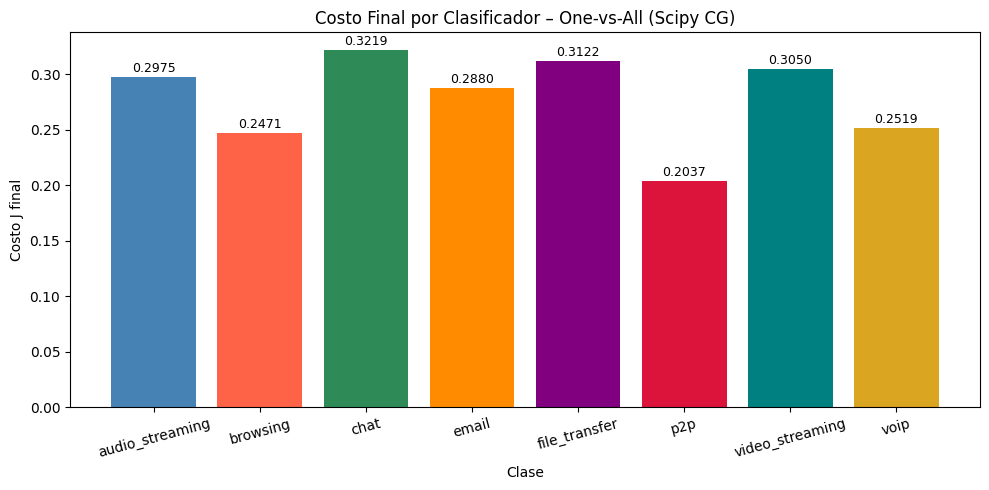


Costo final por clase (Scipy)
  audio_streaming     : J = 0.2975
  browsing            : J = 0.2471
  chat                : J = 0.3219
  email               : J = 0.2880
  file_transfer       : J = 0.3122
  p2p                 : J = 0.2037
  video_streaming     : J = 0.3050
  voip                : J = 0.2519


In [25]:
m_tr     = X_train.shape[0]
X_train_b = np.concatenate([np.ones((m_tr, 1)), X_train], axis=1)

costos_finales = []
for c in range(num_labels):
    y_c = (y_train == c).astype(float)
    J, _ = lrCostFunction(all_theta_om[c], X_train_b, y_c, lambda_)
    costos_finales.append(J)

pyplot.figure(figsize=(10, 5))
bars = pyplot.bar(nombres_clases, costos_finales, color=colores)
pyplot.xlabel('Clase')
pyplot.ylabel('Costo J final')
pyplot.title('Costo Final por Clasificador – One-vs-All (Scipy CG)')
pyplot.xticks(rotation=15)
for i, (nombre, costo) in enumerate(zip(nombres_clases, costos_finales)):
    pyplot.text(i, costo + 0.002, f'{costo:.4f}',
                ha='center', va='bottom', fontsize=9)
pyplot.tight_layout()
pyplot.show()

print('\nCosto final por clase (Scipy)')
for c in range(num_labels):
    print(f'  {idx_a_clase[c]:20s}: J = {costos_finales[c]:.4f}')

In [26]:

print('RESUMEN LAB 4')

print(f'Dataset        : CIC-Darknet2020')
print(f'Target         : Label.1 (tipo de actividad)')
print(f'Clases         : {num_labels} → {list(idx_a_clase.values())}')
print(f'Features       : {X_train.shape[1]}')
print(f'Balanceo       : Undersampling + SMOTE → 10,000/clase')
print(f'Train / Test   : {X_train.shape[0]} / {X_test.shape[0]} muestras')
print(f'Alpha (GD)     : {alpha}')
print(f'Iteraciones GD : {num_iters}')
print(f'Lambda         : {lambda_}')

print(f'Precisión Entrenamiento (GD)     : {acc_train_gd:.2f}%')
print(f'Precisión Prueba        (GD)     : {acc_test_gd:.2f}%')
print(f'Precisión Entrenamiento (Scipy)  : {acc_train_om:.2f}%')
print(f'Precisión Prueba        (Scipy)  : {acc_test_om:.2f}%')


RESUMEN LAB 4
Dataset        : CIC-Darknet2020
Target         : Label.1 (tipo de actividad)
Clases         : 8 → ['audio_streaming', 'browsing', 'chat', 'email', 'file_transfer', 'p2p', 'video_streaming', 'voip']
Features       : 77
Balanceo       : Undersampling + SMOTE → 10,000/clase
Train / Test   : 80000 / 20625 muestras
Alpha (GD)     : 0.1
Iteraciones GD : 3000
Lambda         : 0.01
Precisión Entrenamiento (GD)     : 47.18%
Precisión Prueba        (GD)     : 55.61%
Precisión Entrenamiento (Scipy)  : 49.51%
Precisión Prueba        (Scipy)  : 57.67%


## 14. Serialización y Guardado ("Persistencia de Datos")
 Guardamos todos nuestros pesos matemáticos finales (`all_theta_om.npy`), la configuración media y desviaciones que usamos ($Z$-score de test: `mu.npy` y `sigma.npy`), e id de clases dentro de ficheros locales estáticos. Así nunca tendremos que volver atrás para reentrenar.

In [27]:
import json

# Guardar todo lo necesario para predicción futura
np.save('all_theta_om.npy', all_theta_om)
np.save('all_theta_gd.npy', all_theta_gd)
np.save('mu.npy', mu)
np.save('sigma.npy', sigma)

# Guardar mapeo de clases en JSON
with open('clases.json', 'w') as f:
    json.dump({
        'idx_a_clase': idx_a_clase,
        'clase_a_idx': clase_a_idx,
        'num_labels':  num_labels
    }, f)

print('Archivos guardados:')
print('  all_theta_om.npy  → parámetros Scipy (modelo principal)')
print('  all_theta_gd.npy  → parámetros Descenso Gradiente')
print('  mu.npy            → medias de normalización')
print('  sigma.npy         → desviaciones estándar de normalización')
print('  clases.json       → mapeo índice ↔ nombre de clase')
print(f'\nForma all_theta_om : {all_theta_om.shape}')
print(f'Forma mu           : {mu.shape}')
print(f'Forma sigma        : {sigma.shape}')

Archivos guardados:
  all_theta_om.npy  → parámetros Scipy (modelo principal)
  all_theta_gd.npy  → parámetros Descenso Gradiente
  mu.npy            → medias de normalización
  sigma.npy         → desviaciones estándar de normalización
  clases.json       → mapeo índice ↔ nombre de clase

Forma all_theta_om : (8, 78)
Forma mu           : (77,)
Forma sigma        : (77,)


## 14.5 Persistencia de Variables Clave para Inicio Rápido de Gradio
Guardamos metadatos mínimos para poder levantar inferencia sin recalcular todo el flujo desde cero: nombres de variables, variables importantes, vector base por defecto y ejemplos reales de referencia.

In [28]:
import json
import numpy as np

# Variables base del modelo
feature_names_meta = X_raw_df.columns.tolist()
num_features_meta  = len(feature_names_meta)

# Variables importantes basadas en magnitud promedio de theta (sin bias)
theta_sin_bias_meta  = all_theta_om[:, 1:]
importancias_meta    = np.mean(np.abs(theta_sin_bias_meta), axis=0)
top_k_meta           = min(12, num_features_meta)
idx_importantes_meta = np.argsort(importancias_meta)[-top_k_meta:][::-1]

# TODOS los ejemplos del test con sus etiquetas reales
num_ejemplos_meta = X_test_raw.shape[0]  # todos, no solo 5

print(f'Guardando {num_ejemplos_meta} ejemplos del set de prueba...')

ejemplos_vector_completo_meta = [
    X_test_raw[i].astype(float).tolist()
    for i in range(num_ejemplos_meta)
]

# Etiquetas reales de cada ejemplo
etiquetas_reales_meta = [
    idx_a_clase[int(y_test[i])]
    for i in range(num_ejemplos_meta)
]

# Ejemplos recortados solo a variables importantes (para examples de UI)
ejemplos_variables_importantes_meta = [
    [float(X_test_raw[i][idx]) for idx in idx_importantes_meta]
    for i in range(min(10, num_ejemplos_meta))
]

gradio_metadata = {
    'feature_names'               : feature_names_meta,
    'num_features'                : num_features_meta,
    'idx_importantes'             : [int(i)   for i in idx_importantes_meta],
    'importancias'                : [float(v) for v in importancias_meta],
    'vector_base_default'         : X_test_raw.mean(axis=0).astype(float).tolist(),
    'ejemplos_vector_completo'    : ejemplos_vector_completo_meta,
    'ejemplos_variables_importantes': ejemplos_variables_importantes_meta,
    'etiquetas_reales'            : etiquetas_reales_meta,
    'top_k'                       : int(top_k_meta)
}

with open('gradio_metadata.json', 'w') as f:
    json.dump(gradio_metadata, f)

print('✅ gradio_metadata.json guardado correctamente')
print(f'   Variables totales     : {num_features_meta}')
print(f'   Variables importantes : {top_k_meta}')
print(f'   Ejemplos guardados    : {num_ejemplos_meta}')
print(f'   Etiquetas reales      : {len(etiquetas_reales_meta)}')
print(f'\nDistribución de etiquetas en ejemplos guardados:')
from collections import Counter
conteo = Counter(etiquetas_reales_meta)
for clase, cantidad in sorted(conteo.items()):
    print(f'   {clase:20s}: {cantidad}')


Guardando 20625 ejemplos del set de prueba...
✅ gradio_metadata.json guardado correctamente
   Variables totales     : 77
   Variables importantes : 12
   Ejemplos guardados    : 20625
   Etiquetas reales      : 20625

Distribución de etiquetas en ejemplos guardados:
   audio_streaming     : 2268
   browsing            : 6130
   chat                : 2057
   email               : 1051
   file_transfer       : 2066
   p2p                 : 4627
   video_streaming     : 1798
   voip                : 628


In [29]:
import json

# Cargar parámetros guardados
all_theta_cargado = np.load('all_theta_om.npy')
mu_cargado        = np.load('mu.npy')
sigma_cargado     = np.load('sigma.npy')

with open('clases.json', 'r') as f:
    datos_clases = json.load(f)

idx_a_clase_cargado = {int(k): v for k, v in datos_clases['idx_a_clase'].items()}
num_labels_cargado  = datos_clases['num_labels']

def predecir_muestra(muestra_array):
    """
    Recibe un array numpy de 77 features y retorna
    la clase predicha sin necesidad de reentrenar.
    """
    muestra_norm = (muestra_array - mu_cargado) / sigma_cargado
    muestra_b    = np.concatenate([[1], muestra_norm])
    probs        = sigmoid(muestra_b.dot(all_theta_cargado.T))
    clase_idx    = np.argmax(probs)
    return idx_a_clase_cargado[clase_idx], probs

# Prueba rápida con primera muestra del conjunto de prueba
muestra_prueba        = X_test_raw[0]
clase_pred, probs     = predecir_muestra(muestra_prueba)
clase_real            = idx_a_clase[int(y_test[0])]

print(f'Clase real      : {clase_real}')
print(f'Clase predicha  : {clase_pred}')
print(f'\nProbabilidades por clase:')
for c in range(num_labels_cargado):
    print(f'  {idx_a_clase_cargado[c]:20s}: {probs[c]:.4f}')

Clase real      : p2p
Clase predicha  : p2p

Probabilidades por clase:
  audio_streaming     : 0.0218
  browsing            : 0.2875
  chat                : 0.0101
  email               : 0.0508
  file_transfer       : 0.1742
  p2p                 : 0.7138
  video_streaming     : 0.0361
  voip                : 0.0090


In [30]:
!pip install gradio -q

import gradio as gr
import numpy as np
import json

# Cargar parametros del modelo
all_theta_gr = np.load('all_theta_om.npy')
mu_gr        = np.load('mu.npy')
sigma_gr     = np.load('sigma.npy')

with open('clases.json', 'r') as f:
    datos_clases = json.load(f)

idx_a_clase_gr = {int(k): v for k, v in datos_clases['idx_a_clase'].items()}
num_labels_gr  = datos_clases['num_labels']

with open('gradio_metadata.json', 'r') as f:
    gradio_meta = json.load(f)

feature_names            = gradio_meta['feature_names']
n_features               = int(gradio_meta['num_features'])
idx_importantes          = np.array(gradio_meta['idx_importantes'], dtype=int)
importancias             = np.array(gradio_meta['importancias'], dtype=np.float64)
vector_base_default      = np.array(gradio_meta['vector_base_default'], dtype=np.float64)
ejemplos_vector_completo = gradio_meta.get('ejemplos_vector_completo', [])
top_k                    = len(idx_importantes)
nombres_importantes      = [feature_names[i] for i in idx_importantes]

# ── Necesitamos TODOS los ejemplos del test, no solo 5 ──────────────────────
# Guardar todos en metadata requiere reejecutar celda 20.
# Si solo tienes 5, el slider va de 0 a 4.
n_ejemplos = len(ejemplos_vector_completo)

# Etiquetas de clase reales para cada ejemplo (guardadas en metadata si existe)
etiquetas_reales = gradio_meta.get('etiquetas_reales', [None] * n_ejemplos)

info_variables = {
    'Avg Packet Size':              ('Tamaño Promedio de Paquete',        'bytes'),
    'Packet Length Mean':           ('Longitud Media de Paquete',         'bytes'),
    'Subflow Fwd Bytes':            ('Bytes Subflujo Saliente',           'bytes'),
    'Idle Max':                     ('Tiempo Máximo Inactivo',            'microsegundos'),
    'Idle Mean':                    ('Tiempo Inactivo Promedio',          'microsegundos'),
    'Total Length of Bwd Packet':   ('Longitud Total Paquetes Entrantes', 'bytes'),
    'Subflow Bwd Bytes':            ('Bytes Subflujo Entrante',           'bytes'),
    'ACK Flag Count':               ('Conteo Flags ACK',                  'paquetes'),
    'Flow Bytes/s':                 ('Bytes por Segundo del Flujo',       'bytes/s'),
    'Bwd Header Length':            ('Longitud Cabecera Entrante',        'bytes'),
    'Fwd Header Length':            ('Longitud Cabecera Saliente',        'bytes'),
    'Packet Length Max':            ('Longitud Máxima de Paquete',        'bytes'),
}

def etiqueta_input(nombre):
    if nombre in info_variables:
        traduccion, unidad = info_variables[nombre]
        return f'{nombre} | {traduccion} | {unidad}'
    return nombre

def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1.0 / (1.0 + np.exp(-z))

def predecir_gradio(indice_ejemplo, *valores_importantes):
    idx     = int(np.clip(int(indice_ejemplo), 0, n_ejemplos - 1))
    muestra = np.array(ejemplos_vector_completo[idx], dtype=np.float64)

    # Valores originales del ejemplo para detectar ediciones
    originales = np.array(ejemplos_vector_completo[idx], dtype=np.float64)

    # Detectar si el usuario editó algún valor
    editado = False
    for pos, idx_var in enumerate(idx_importantes):
        val = valores_importantes[pos]
        if val is None:
            continue
        if isinstance(val, float) and (np.isnan(val) or np.isinf(val)):
            continue
        if abs(float(val) - float(originales[idx_var])) > 1e-9:
            editado = True
        muestra[idx_var] = float(val)

    # Normalizar y predecir
    muestra_norm = (muestra - mu_gr) / sigma_gr
    muestra_b    = np.concatenate([[1.0], muestra_norm])
    probs_raw    = sigmoid(muestra_b.dot(all_theta_gr.T))

    # Softmax para que probabilidades sumen 1
    e_x   = np.exp(probs_raw - np.max(probs_raw))
    probs = e_x / e_x.sum()

    clase_idx    = int(np.argmax(probs))
    clase_nombre = idx_a_clase_gr[clase_idx]
    confianza    = float(np.max(probs) * 100)

    # Resultado esperado (solo si no fue editado)
    if not editado and etiquetas_reales[idx] is not None:
        esperado     = etiquetas_reales[idx].upper()
        correcto     = '✅ CORRECTO' if esperado == clase_nombre.upper() else '❌ INCORRECTO'
        linea_esp    = f'Resultado esperado : {esperado}  {correcto}\n'
    else:
        linea_esp    = 'Resultado esperado : (valores editados manualmente)\n'

    top3_idx = np.argsort(probs)[-3:][::-1]
    top3_txt = '\n'.join([
        f'  {idx_a_clase_gr[int(i)].upper()}: {float(probs[int(i)])*100:.2f}%'
        for i in top3_idx
    ])

    resumen = (
        f'Ejemplo real #{idx} del set de prueba\n'
        f'{"─"*42}\n'
        f'Actividad predicha : {clase_nombre.upper()}\n'
        f'Confianza          : {confianza:.2f}%\n'
        f'{linea_esp}'
        f'{"─"*42}\n'
        f'Top 3 probabilidades:\n{top3_txt}'
    )

    probabilidades_dict = {
        idx_a_clase_gr[c]: float(probs[c])
        for c in range(num_labels_gr)
    }

    return resumen, probabilidades_dict

# ── Inputs ───────────────────────────────────────────────────────────────────
inputs = [
    gr.Slider(
        minimum=0,
        maximum=n_ejemplos - 1,
        step=1,
        value=0,
        label=f'Ejemplo real del set de prueba (0 al {n_ejemplos - 1})'
    )
]

defaults_importantes = [
    float(round(ejemplos_vector_completo[0][idx], 6))
    for idx in idx_importantes
]

for i in range(top_k):
    inputs.append(
        gr.Number(
            label=etiqueta_input(nombres_importantes[i]),
            value=defaults_importantes[i]
        )
    )

# ── Outputs ──────────────────────────────────────────────────────────────────
outputs = [
    gr.Textbox(label='Resultado de la predicción', lines=12),
    gr.Label(label='Probabilidades por tipo de actividad de red')
]

# ── Ejemplos rapidos: primeros 10 ────────────────────────────────────────────
examples = []
for i in range(min(10, n_ejemplos)):
    fila = [i] + [
        float(round(ejemplos_vector_completo[i][idx], 6))
        for idx in idx_importantes
    ]
    examples.append(fila)

interfaz = gr.Interface(
    fn=predecir_gradio,
    inputs=inputs,
    outputs=outputs,
    title='🌐 Clasificador de Tráfico de Red — CIC-Darknet2020',
    description=(
        'Selecciona cualquier ejemplo real del set de prueba con el slider. '
        'Si no editas valores verás el resultado esperado vs predicho. '
        'Si editas algún valor los campos se marcan como modificados manualmente.'
    ),
    examples=examples,
    theme=gr.themes.Soft(),
    flagging_mode='never',
    submit_btn='Predecir actividad',
    clear_btn='Restablecer'
)

interfaz.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://c11660629d2ed37908.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
